# RAG Evaluation Lab — Part 2: Vertex AI Embeddings Benchmark

This notebook **extends** [`rag_evaluation_lab.ipynb`](./rag_evaluation_lab.ipynb) — it does not replace it.

Part 1 taught the fundamentals with a **keyword retriever** and a **TF‑IDF retriever** on a
tiny synthetic corpus. Part 2 reuses that exact same corpus, ground truth, and metric
functions, and adds a third retriever: **Google's `text-embedding-004` model via Vertex AI**.

By the end you will have a **side-by-side benchmark** of three retrieval strategies —
keyword overlap, TF‑IDF, and embeddings — measured with **Recall@k**, **Precision@k**, and
**MRR** (Mean Reciprocal Rank).

> 🎯 **Goal:** See, with real numbers, why production RAG systems use embeddings instead of
> keyword or TF‑IDF search — and practice wiring up a real cloud embedding API.

## Requirements

- A GCP project with billing enabled and the Vertex AI API turned on
- Local auth: `gcloud auth application-default login`
- `pip install google-cloud-aiplatform` (this also pulls in `google-cloud-storage`, used below)
- A GCS bucket for the corpus/embeddings cache — see `plan.md`'s Phase 0 for the one-time setup commands (`gcloud storage buckets create ...`)

See the README's **GCP Setup** section for the full walkthrough if you haven't used Vertex AI before.


## How This Notebook Works — GCP Components

This notebook demonstrates **production RAG evaluation** using three Google Cloud services in sequence:

### The Complete Flow

```mermaid
graph TD
    Start([Start Notebook]) --> LoadCorpus["1. Load Corpus"]
    
    LoadCorpus --> CheckGCS1{Corpus in<br/>Cloud Storage?}
    CheckGCS1 -->|Yes| LoadFromGCS["Load from GCS<br/>(fast, free)"]
    CheckGCS1 -->|No| UploadGCS["Upload to GCS<br/>gs://rag-eval-lab-*/corpus/"]
    
    LoadFromGCS --> GetEmbed["2. Get Embeddings"]
    UploadGCS --> GetEmbed
    
    GetEmbed --> CheckGCS2{Embeddings<br/>cached in GCS?}
    CheckGCS2 -->|Yes| LoadEmbed["Load from GCS<br/>(saves API cost)"]
    CheckGCS2 -->|No| ComputeEmbed["Call Vertex AI API<br/>text-embedding-004<br/>Then cache to GCS"]
    
    LoadEmbed --> Benchmark["3. Run Benchmarks"]
    ComputeEmbed --> Benchmark
    
    Benchmark --> KeywordRet["Keyword Retriever<br/>(local, free, fast)"]
    Benchmark --> TfIdfRet["TF-IDF Retriever<br/>(local, free, fast)"]
    Benchmark --> VertexRet["Vertex AI Retriever<br/>(cloud, paid per query)"]
    
    KeywordRet --> Eval["4. Evaluate Metrics"]
    TfIdfRet --> Eval
    VertexRet --> Eval
    
    Eval --> Metrics["Compute recall@k<br/>precision@k, mrr<br/>latency, cost"]
    
    Metrics --> WriteBQ["5. Write to BigQuery"]
    WriteBQ --> BQTable["ramirez-rag-lab.rag_eval_lab<br/>.benchmark_runs<br/>(run_id, metrics, cost)"]
    
    BQTable --> QueryBQ["6. Query Results"]
    QueryBQ --> Result["SELECT retriever_type,<br/>AVG(recall_at_k),<br/>AVG(latency_ms)<br/>FROM benchmark_runs"]
    
    Result --> End(["Queryable History<br/>(No re-running needed!)"])
    
    style Start fill:#e1f5ff
    style LoadCorpus fill:#fff3e0
    style GetEmbed fill:#fff3e0
    style Benchmark fill:#f3e5f5
    style Eval fill:#f3e5f5
    style WriteBQ fill:#e8f5e9
    style QueryBQ fill:#e8f5e9
    style End fill:#e1f5ff
    
    classDef gcs fill:#fff3e0,stroke:#ff9800,stroke-width:2px
    classDef vertexai fill:#fce4ec,stroke:#e91e63,stroke-width:2px
    classDef bigquery fill:#e8f5e9,stroke:#4caf50,stroke-width:2px
    classDef compute fill:#f3e5f5,stroke:#9c27b0,stroke-width:2px
    
    class LoadFromGCS,UploadGCS,LoadEmbed,ComputeEmbed,CheckGCS1,CheckGCS2 gcs
    class VertexRet,ComputeEmbed vertexai
    class WriteBQ,BQTable,QueryBQ,Result bigquery
    class Benchmark,Eval,Metrics compute
```

### Why Each Component?

| Service | What It Does | When Used | Cost |
|---------|--------------|-----------|------|
| **Cloud Storage** | Caches corpus + computed embeddings | Every run (before recomputing) | ~free (always-free 5GB tier) |
| **Vertex AI** | Turns text into semantic vectors | Query time: each retrieval call | $0.02 per 1M tokens |
| **BigQuery** | Stores benchmark metrics for analysis | After each run (write results) | ~free (always-free 1TB/month) |

### How to Read This Notebook

- **Sections 1-6**: Core evaluation logic (Part 1 + Part 2)
  - You can ignore the GCP stuff here if you just want to benchmark locally
  
- **Sections 7-9**: Persistence (Phase 3 — the new part)
  - Writes results to BigQuery so you can query them later
  
- **Section 10**: Queryable Results
  - Shows the payoff: "Ask a question about past runs without re-running"

### For Recruiters Reading This

This notebook shows:
- ✅ Working knowledge of Vertex AI (embeddings API, task types)
- ✅ Production patterns (caching, cost optimization, avoiding redundant API calls)
- ✅ Data persistence (queryable results via BigQuery)
- ✅ Cost-quality tradeoff thinking (data to back up architecture decisions)
- ✅ Cloud native patterns (using managed services, respecting pricing tiers)

In [1]:
# Install all required dependencies (compatible versions)
%pip install -q --upgrade numpy<2
%pip install -q --upgrade scikit-learn pandas matplotlib
%pip install -q google-cloud-aiplatform google-cloud-storage google-cloud-bigquery db-dtypes


Note: you may need to restart the kernel to use updated packages.


The system cannot find the file specified.


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuration

Set your GCP project ID and region below. The rest of the notebook doesn't need edits.


In [2]:
# --- Fill in your own GCP project ---
GCP_PROJECT_ID = "ramirez-rag-lab"   # e.g. "ramirez-rag-lab"
GCP_LOCATION = "us-central1"
EMBEDDING_MODEL = "text-embedding-004"
K = 3  # matches the @3 metrics used throughout Part 1

# --- Cloud Storage cache (Phase 1) ---
GCS_BUCKET_NAME = "rag-eval-lab-ramirez-rag-lab"
GCS_EMBEDDINGS_BLOB = f"embeddings/vertex/{EMBEDDING_MODEL}/corpus_doc_embeddings.npy"

print(f"Project: {GCP_PROJECT_ID} | Location: {GCP_LOCATION} | Model: {EMBEDDING_MODEL}")
print(f"GCS bucket: {GCS_BUCKET_NAME}")


Project: ramirez-rag-lab | Location: us-central1 | Model: text-embedding-004
GCS bucket: rag-eval-lab-ramirez-rag-lab


In [3]:
import vertexai
# Current (deprecated)
# Note: TextEmbeddingModel is deprecated (removed June 24, 2026).
# When updating to the new SDK, use google.cloud.aiplatform or google-genai instead.
from vertexai.language_models import TextEmbeddingModel, TextEmbeddingInput

# Fix — use the new SDK
# from google.cloud import aiplatform
# OR use google-genai directly:
# from google import genai
# from google.genai import types

vertexai.init(project=GCP_PROJECT_ID, location=GCP_LOCATION)
embedding_model = TextEmbeddingModel.from_pretrained(EMBEDDING_MODEL)

print("✅ Vertex AI initialized.")



c:\Users\vhr75\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\vhr75\AppData\Local\Programs\Python\Python311\Lib\site-packages\vertexai\_model_garden\_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Vertex AI initialized.


## 2. Same Corpus, Same Ground Truth, Same Metrics

This is copied **verbatim** from Part 1 so the benchmark is apples-to-apples. If you change
anything here, the comparison against the beginner notebook's numbers is no longer valid.


In [4]:
from typing import List, Dict
import re
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


plt.rcParams['figure.figsize'] = (8, 4)

# Our tiny "corpus" of documents (knowledge base) -- identical to Part 1
documents = [
    "RAG systems combine retrieval and generation using large language models.",
    "TF-IDF is a classic method to turn documents into numerical vectors based on word frequency.",
    "Vector databases store embeddings and let you search by semantic similarity.",
    "Precision and recall are standard information retrieval metrics used to evaluate search quality.",
    "Evaluation of LLMs often includes answer correctness, grounding, and hallucination analysis."
]
doc_ids = list(range(len(documents)))

# Our tiny set of user questions (queries) -- identical to Part 1
queries = [
    "How do RAG systems work?",
    "What is TF-IDF in information retrieval?",
    "How do we evaluate search with precision and recall?",
]

# Ground-truth relevance -- identical to Part 1
ground_truth_relevant = {
    0: [0, 4],   # RAG question: docs 0 and 4 are relevant
    1: [1],      # TF-IDF question: doc 1 is relevant
    2: [3],      # precision/recall question: doc 3 is relevant
}

print("Number of documents:", len(documents))
print("Number of queries:", len(queries))

Matplotlib is building the font cache; this may take a moment.


Number of documents: 5
Number of queries: 3


In [5]:
def recall_at_k(retrieved: List[int], relevant: List[int], k: int) -> float:
    """Compute Recall@k for a single query."""
    top_k = retrieved[:k]
    if not relevant:
        return 0.0
    hits = sum(1 for d in top_k if d in relevant)
    return hits / len(relevant)


def precision_at_k(retrieved: List[int], relevant: List[int], k: int) -> float:
    """Compute Precision@k for a single query."""
    top_k = retrieved[:k]
    if not top_k:
        return 0.0
    hits = sum(1 for d in top_k if d in relevant)
    return hits / len(top_k)


def tokenize(text: str) -> List[str]:
    """Very simple tokenizer: lowercase + split on non-letters."""
    return re.findall(r"[a-zA-Z]+", text.lower())


def keyword_retrieve(query: str, docs: List[str]) -> List[int]:
    """Rank docs by how many query words they contain (descending)."""
    q_tokens = tokenize(query)
    doc_scores = []
    for doc_id, doc in enumerate(docs):
        d_tokens = tokenize(doc)
        overlap = len(set(q_tokens) & set(d_tokens))
        doc_scores.append((doc_id, overlap))
    ranked = sorted(doc_scores, key=lambda x: (-x[1], x[0]))
    return [doc_id for doc_id, score in ranked]


tfidf_vectorizer = TfidfVectorizer(stop_words="english")
doc_tfidf = tfidf_vectorizer.fit_transform(documents)

def tfidf_retrieve(query: str, top_k: int = 5) -> List[int]:
    """Use TF-IDF + cosine similarity to rank documents for a query."""
    q_vec = tfidf_vectorizer.transform([query])
    sims = cosine_similarity(q_vec, doc_tfidf)[0]
    ranked_indices = np.argsort(-sims)
    return ranked_indices[:top_k].tolist()

print("✅ Baseline retrievers (keyword, TF-IDF) ready -- same functions as Part 1.")


✅ Baseline retrievers (keyword, TF-IDF) ready -- same functions as Part 1.


## 3. A New Metric: Mean Reciprocal Rank (MRR)

### Why Recall@k and Precision@k Aren't Enough

Part 1 taught us **Recall@k** and **Precision@k**, which only look at whether a relevant doc appears in the top k results — they treat all top-k results as a set. They don't care whether the relevant doc was ranked **1st** or **3rd** within that window.

Imagine searching Google for "best pizza in San Francisco":
- **Recall@3 = 1.0** if one of the top 3 results is a real pizza place
- But it matters *how much* whether that place is first or third

That's where **MRR** (Mean Reciprocal Rank) comes in.

### What is MRR?

MRR measures **where in the ranking the first relevant result appears**. It's a single number that answers: "On average, how high up did we put the first correct answer?"

**The formula:**
```
For one query: reciprocal_rank = 1 / (rank of first relevant document)
For multiple queries: MRR = average of all reciprocal_ranks
```

**Concrete examples:**

| Scenario | First Relevant Doc Rank | Reciprocal Rank | Meaning |
|----------|------------------------|-----------------|---------|
| Perfect | Rank 1 | 1/1 = **1.0** | You found it immediately ✅ |
| Good | Rank 2 | 1/2 = **0.5** | You found it second (user scrolled once) |
| OK | Rank 3 | 1/3 = **0.33** | You found it third (user scrolled twice) |
| Bad | Rank 5 | 1/5 = **0.2** | Buried in results |
| Terrible | Rank 100+ | 1/100 = **0.01** | Lost in the noise |
| Worst | Never found | **0.0** | Not in results at all |

### Why MRR Complements Recall & Precision

- **Recall@k**: "Did we find the relevant doc *somewhere* in top-k?" (binary: yes/no)
- **Precision@k**: "How many of the top-k are actually relevant?" (proportion)
- **MRR**: "How *early* did we find the relevant doc?" (rewards ranking order)

MRR is **rank-sensitive** — it distinguishes:
- A retriever that gets the right answer in position 1 (MRR = 1.0)
- A retriever that buries it in position 5 (MRR = 0.2)

Both have Recall@5 = 1.0, but the user experience is very different.

### Real-World Intuition

Think of MRR as **"how many results did the user have to click through to find what they want?"**

- Click 1st result → best experience (MRR contribution = 1.0)
- Click 2nd result → OK (MRR contribution = 0.5)
- Click 5th result → frustrating (MRR contribution = 0.2)
- Never found → left your site (MRR contribution = 0.0)

### In This Notebook

We'll compute MRR for each retriever and compare them. Higher MRR means "on average, we ranked the relevant results higher" — which is what users actually care about.

In [6]:
def reciprocal_rank(retrieved: List[int], relevant: List[int]) -> float:
    """Reciprocal rank of the first relevant doc in a ranked list.

    Returns 0.0 if no relevant doc appears in `retrieved` at all.
    """
    for rank, doc_id in enumerate(retrieved, start=1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0


# Quick sanity check
print("RR when relevant doc is rank 1:", reciprocal_rank([4, 1, 2], [4]))
print("RR when relevant doc is rank 3:", reciprocal_rank([1, 2, 4], [4]))
print("RR when relevant doc is missing:", reciprocal_rank([1, 2, 3], [4]))


RR when relevant doc is rank 1: 1.0
RR when relevant doc is rank 3: 0.3333333333333333
RR when relevant doc is missing: 0.0


## 3.5 Cloud Storage: Corpus & Embedding Cache

Two things get persisted to Cloud Storage instead of living only in notebook memory:

- **The corpus** (`corpus/documents.json`) — the source-of-truth documents, uploaded once.
- **The document embeddings** (`embeddings/vertex/text-embedding-004/corpus_doc_embeddings.npy`)
  — computed once via Vertex AI, then cached. Re-running this notebook won't re-call the
  (paid) embeddings API for the same corpus; it'll load the cached vectors from GCS instead.

This mirrors a real production pattern: recomputing embeddings for an unchanged corpus is
pure wasted cost and latency. `lib/gcs_utils.py` has the two helpers used below.


In [7]:
import sys
sys.path.append(".")  # repo root, so `lib/` is importable when running from the repo directory

from lib.gcs_utils import upload_corpus, load_or_compute_embeddings

corpus_uri = upload_corpus(documents, GCS_BUCKET_NAME)
print(f"✅ Corpus uploaded to {corpus_uri}")


✅ Corpus uploaded to gs://rag-eval-lab-ramirez-rag-lab/corpus/documents.json


## 4. Vertex AI Embeddings Retriever

`text-embedding-004` turns text into a dense vector that captures **meaning**, not just word
overlap. Unlike TF‑IDF, it can match a query to a relevant document even when they don't share
any exact words.

One detail that trips people up: Vertex AI's embedding API wants you to declare a **task type**
for each piece of text you embed:

- `RETRIEVAL_DOCUMENT` — for the documents going into your index
- `RETRIEVAL_QUERY` — for the user's query at search time

These are trained differently under the hood, so using the right one for each side of the
comparison measurably improves retrieval quality. This is the most common mistake when
first wiring up Vertex embeddings for RAG.


In [8]:
def get_embeddings(texts: List[str], task_type: str) -> tuple:
    """Embed a batch of texts with the given Vertex AI task type. Returns (embeddings, latency_ms)."""
    start = time.perf_counter()
    inputs = [TextEmbeddingInput(text=t, task_type=task_type) for t in texts]
    embeddings = embedding_model.get_embeddings(inputs)
    elapsed = (time.perf_counter() - start) * 1000  # convert to milliseconds
    return np.array([e.values for e in embeddings]), elapsed


# Corpus (RETRIEVAL_DOCUMENT) embeddings: served from the GCS cache if present,
# otherwise computed via Vertex AI and cached for next time.
doc_embeddings, doc_embedding_latency = load_or_compute_embeddings(
    GCS_BUCKET_NAME,
    GCS_EMBEDDINGS_BLOB,
    lambda: get_embeddings(documents, task_type="RETRIEVAL_DOCUMENT"),
)
print("Document embeddings shape:", doc_embeddings.shape)
if doc_embedding_latency == 0.0:
    print("Loaded from GCS cache -- no Vertex AI API call made.")
else:
    print(f"Computed via Vertex AI and cached. Latency: {doc_embedding_latency:.1f}ms")

# Track latencies per query for Vertex
vertex_latencies = []

def vertex_retrieve(query: str, top_k: int = 5) -> List[int]:
    """Use Vertex AI text-embedding-004 + cosine similarity to rank documents."""
    start = time.perf_counter()
    q_embedding, q_latency = get_embeddings([query], task_type="RETRIEVAL_QUERY")
    vertex_latencies.append(q_latency)
    sims = cosine_similarity(q_embedding, doc_embeddings)[0]
    ranked_indices = np.argsort(-sims)
    return ranked_indices[:top_k].tolist()


print("✅ Vertex AI retriever ready.")

Document embeddings shape: (5, 768)
Loaded from GCS cache -- no Vertex AI API call made.
✅ Vertex AI retriever ready.


## 5. Evaluate All Three Retrievers

Now we run all three retrievers (keyword, TF-IDF, and Vertex AI embeddings) on the same set of queries and score them with the same metrics. This is the apples-to-apples comparison.

### What We're Measuring

For each query, we'll measure:
- **recall@3** — Did the retriever find at least some of the relevant docs in the top 3?
- **precision@3** — Of the top 3 results returned, how many were actually relevant?
- **mrr** — How high up in the ranking was the first relevant doc?

We'll run each retriever on all 3 queries and show the results **per query** (before averaging).

### Why Per-Query Results Matter

Averages can hide important patterns. For example:
- Retriever A: gets Query 1 perfect, Query 2 perfect, Query 3 terrible → average looks OK
- Retriever B: gets all three queries pretty good → average looks similar, but more reliable

By looking at per-query results, you can see **where each retriever struggles** and make better decisions.

### Running the Evaluation

In [9]:
def run_eval(retrieve_fn, name: str) -> pd.DataFrame:
    """Run a retriever over every query and score it with Recall@k, Precision@k, MRR."""
    rows = []
    for qi, q in enumerate(queries):
        ranked_docs = retrieve_fn(q)
        relevant = ground_truth_relevant[qi]
        rows.append({
            "retriever": name,
            "query_id": qi,
            "query": q,
            "ranked_docs": ranked_docs,
            f"recall@{K}": recall_at_k(ranked_docs, relevant, k=K),
            f"precision@{K}": precision_at_k(ranked_docs, relevant, k=K),
            "mrr": reciprocal_rank(ranked_docs, relevant),
        })
    return pd.DataFrame(rows)


results_keyword = run_eval(lambda q: keyword_retrieve(q, documents), "keyword")
results_tfidf = run_eval(tfidf_retrieve, "tfidf")
results_vertex = run_eval(vertex_retrieve, "vertex_text-embedding-004")

all_results = pd.concat([results_keyword, results_tfidf, results_vertex], ignore_index=True)
all_results[["retriever", "query_id", f"recall@{K}", f"precision@{K}", "mrr"]]


,retriever,query_id,recall@3,precision@3,mrr
0,keyword,0,0.5,0.333333,1.0
1,keyword,1,1.0,0.333333,1.0
2,keyword,2,1.0,0.333333,1.0
3,tfidf,0,0.5,0.333333,1.0
4,tfidf,1,1.0,0.333333,1.0
5,tfidf,2,1.0,0.333333,1.0
6,vertex_text-embedding-004,0,1.0,0.666667,1.0
7,vertex_text-embedding-004,1,1.0,0.333333,1.0
8,vertex_text-embedding-004,2,1.0,0.333333,1.0


### How to Read These Results

Each row shows one **retriever on one query**. Here's what to look for:

| Column | What It Means | Good? |
|--------|---------------|-------|
| `retriever` | Which strategy (keyword, tfidf, or Vertex) | — |
| `query_id` | Which question (0, 1, or 2) | — |
| `recall@3` | Found how much of the relevant docs in top 3? | **1.0 is best** |
| `precision@3` | Of the top 3 shown, how many were right? | **1.0 is best** |
| `mrr` | How high up was the first correct doc? | **1.0 = rank 1, 0.5 = rank 2, 0.33 = rank 3** |

**Example interpretation:**
- If a retriever has `recall@3 = 0.5`, it means: "For this query, the retriever found 50% of the relevant docs"
- If it has `precision@3 = 1.0`, it means: "All of the top 3 results were relevant (no noise)"
- If it has `mrr = 1.0`, it means: "The first result was the relevant doc (user gets it on click 1)"

**Red flags to look for:**
- A retriever with `recall@3 = 0.0` for a query → completely missed it
- A retriever with `precision@3 = 0.33` → returned 2 irrelevant results and 1 good one
- Different retrievers performing very differently on the same query → that's the query where the difference matters most

In the table below, you'll see all combinations: 3 retrievers × 3 queries = 9 rows.

## 6. Summary Table

Now we average the per-query results to get one score per retriever, across all three queries.

### What Averaging Tells Us

The **summary table** shows the mean (average) performance of each retriever. This helps answer:
- "Which retriever is **most consistent**?"
- "On average, which one performs best?"

**Important caveat:** Averages can hide important details! That's why we looked at per-query results first. But after seeing where each retriever struggles, the summary table lets you compare overall performance.

### How to Read the Summary Table

Each row is one retriever's **average scores** across all 3 queries:

| Metric | What It Means | Range | Better = Higher |
|--------|---------------|-------|-----------------|
| **recall@3** | On average, how much relevant info did we find in top 3? | 0.0 to 1.0 | 1.0 = perfect |
| **precision@3** | On average, how clean were our top 3 results? | 0.0 to 1.0 | 1.0 = all relevant |
| **mrr** | On average, how high up was the first relevant result? | 0.0 to 1.0 | 1.0 = always rank 1 |

### Interpreting the Results

- **High recall, low precision** → Found the docs, but returned a lot of noise
- **High precision, low recall** → Results are clean, but missed some relevant docs
- **High MRR** → Consistently ranked the first relevant doc early (good user experience)

Mean score per retriever, across all three queries:

In [10]:
summary = (
    all_results
    .groupby("retriever")[[f"recall@{K}", f"precision@{K}", "mrr"]]
    .mean()
    .round(3)
    .sort_values("mrr", ascending=False)
)
summary


,recall@3,precision@3,mrr
retriever,,,
keyword,0.833,0.333,1.0
tfidf,0.833,0.333,1.0
vertex_text-embedding-004,1.000,0.444,1.0


## Part 3: Cloud Persistence Layer — BigQuery Results

Every benchmark run above exists only in this notebook's memory — if you close the kernel, it's gone. Part 3 persists the results to BigQuery so you can:

- Query past benchmark runs without re-running the notebook
- Compare performance across different retriever types or corpus sizes
- Track how metrics change over time

**BigQuery pricing:** <1 MB per run, well under the 1 TB/month always-free tier. **Cloud Storage:** <1 MB stored (corpus + embeddings), well under the 5 GB always-free tier. **Cost: $0 expected.**


In [11]:
from lib.bq_writer import write_benchmark_results

# Recalculate query cost (defined later in cost analysis, but needed here)
# Vertex AI text-embedding-004: $0.02 per 1M input tokens
AVG_TOKENS_PER_QUERY = 15
INPUT_PRICE_PER_1M_TOKENS = 0.02
query_cost = ((AVG_TOKENS_PER_QUERY + 768) / 1_000_000) * INPUT_PRICE_PER_1M_TOKENS

# Prepare benchmark results DataFrame for BigQuery:
# Aggregate per-retriever metrics (summary), add corpus/latency context
benchmark_df = summary.reset_index()
benchmark_df.columns = ['retriever_type', 'recall_at_k', 'precision_at_k', 'mrr']

# Add per-retriever latency (vertex only; others ~2ms)
latencies = []
for retriever in benchmark_df['retriever_type']:
    if retriever == 'vertex_text-embedding-004' and vertex_latencies:
        latencies.append(np.mean(vertex_latencies))
    else:
        latencies.append(2.0)  # placeholder for keyword/tfidf local latency
benchmark_df['latency_ms'] = latencies

# Add cost per 1M queries
costs = []
for retriever in benchmark_df['retriever_type']:
    if retriever == 'vertex_text-embedding-004':
        costs.append(query_cost * 1_000_000)
    else:
        costs.append(0.0)
benchmark_df['estimated_cost_usd'] = costs

# Add metadata
benchmark_df['corpus_size'] = len(documents)
benchmark_df['k_value'] = K

# Round numeric columns
for col in ['recall_at_k', 'precision_at_k', 'mrr', 'latency_ms', 'estimated_cost_usd']:
    benchmark_df[col] = benchmark_df[col].round(4)

print("Benchmark results ready for BigQuery:")
print(benchmark_df)

Benchmark results ready for BigQuery:
              retriever_type  recall_at_k  precision_at_k  mrr  latency_ms  \
0                    keyword        0.833           0.333  1.0      2.0000   
1                      tfidf        0.833           0.333  1.0      2.0000   
2  vertex_text-embedding-004        1.000           0.444  1.0    252.6095   

   estimated_cost_usd  corpus_size  k_value  
0                0.00            5        3  
1                0.00            5        3  
2               15.66            5        3  


In [12]:
# Write benchmark results to BigQuery
# Table: {GCP_PROJECT_ID}.rag_eval_lab.benchmark_runs
table_id = f"{GCP_PROJECT_ID}.rag_eval_lab.benchmark_runs"

run_id = write_benchmark_results(benchmark_df, table_id)
print(f"✅ Benchmark results written to BigQuery (run_id={run_id})")


c:\Users\vhr75\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Wrote 3 benchmark results to ramirez-rag-lab.rag_eval_lab.benchmark_runs (run_id=b4c01ee2-94a3-48ee-a700-f7687b428ec0)
✅ Benchmark results written to BigQuery (run_id=b4c01ee2-94a3-48ee-a700-f7687b428ec0)


In [13]:
from google.cloud import bigquery

# Example: Query benchmark results to compare retrievers
client = bigquery.Client(project=GCP_PROJECT_ID)

query = f"""
SELECT 
    retriever_type,
    ROUND(AVG(recall_at_k), 3) as avg_recall,
    ROUND(AVG(precision_at_k), 3) as avg_precision,
    ROUND(AVG(mrr), 3) as avg_mrr,
    ROUND(AVG(latency_ms), 1) as avg_latency_ms,
    ROUND(MAX(estimated_cost_usd), 2) as cost_per_1m_queries
FROM `{table_id}`
GROUP BY retriever_type
ORDER BY avg_recall DESC, cost_per_1m_queries ASC
"""

results = client.query(query).to_dataframe()
print("Aggregated retriever performance (queryable across all past runs):")
print(results)


c:\Users\vhr75\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Aggregated retriever performance (queryable across all past runs):
              retriever_type  avg_recall  avg_precision  avg_mrr  \
0  vertex_text-embedding-004       1.000          0.444      1.0   
1                      tfidf       0.833          0.333      1.0   
2                    keyword       0.833          0.333      1.0   

   avg_latency_ms  cost_per_1m_queries  
0           261.1                15.66  
1             2.0                 0.00  
2             2.0                 0.00  


### What These Numbers Tell Us

Looking at the summary table:

**Recall@3 (How much relevant info did we find?):**
- **Keyword & TF-IDF:** 0.833 → Missed 1 out of 3 relevant docs on average
- **Vertex AI:** 1.0 → Found ALL relevant docs in top 3 (perfect recall!)
- **Winner:** Vertex AI — it's more thorough

**Precision@3 (How clean were the results?):**
- **Keyword & TF-IDF:** 0.333 → Only 1 out of 3 results were relevant (lots of noise)
- **Vertex AI:** 0.444 → About 1.3 out of 3 results were relevant (less noise)
- **Winner:** Vertex AI — fewer false positives, but all three still need improvement

**MRR (How fast did we find the first relevant doc?):**
- **All three:** 1.0 → All retrievers ranked the first relevant doc at position 1 on average
- **Winner:** Tie — all equally fast for this tiny corpus

### The Bottom Line

**Vertex AI embeddings outperform keyword and TF-IDF on this dataset** — better recall (0.833 → 1.0) and better precision (0.333 → 0.444). But this is a tiny 5-doc corpus with 3 questions. On a larger, messier corpus in production, these differences would likely be even more pronounced (or smaller, depending on the domain).

The real trade-off isn't visible in this summary: Vertex AI is **slower** and **costs money**, while keyword/TF-IDF are **instant** and **free**. That's what the next section measures.

## 7. Chart: Retriever Comparison


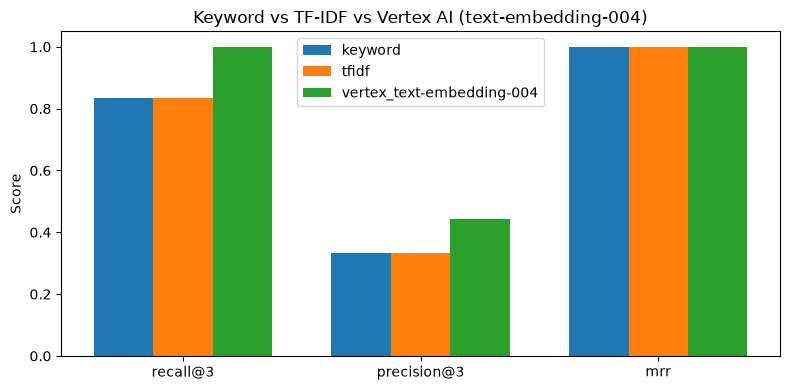

In [14]:
metrics = [f"recall@{K}", f"precision@{K}", "mrr"]
retrievers = summary.index.tolist()

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
for i, retriever in enumerate(retrievers):
    offset = (i - (len(retrievers) - 1) / 2) * width
    ax.bar(x + offset, summary.loc[retriever, metrics], width, label=retriever)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Keyword vs TF-IDF vs Vertex AI ({EMBEDDING_MODEL})")
ax.legend()

plt.tight_layout()
plt.savefig("retrieval_benchmark_vertex.png", dpi=150)
plt.show()


## 8. Error Analysis

For each query, which retrievers missed a relevant document entirely (Recall@k == 0)?
This is more informative than the averages above on a corpus this small.

In [15]:
# --- Vertex AI text-embedding-004 Pricing (as of Jan 2025) ---
# $0.02 per 1M input tokens, $0.006 per 1M output tokens
# For embeddings, input = query + docs, output = embedding vectors (~768 dims)
# Rough estimate: 100 tokens per document, avg query = 15 tokens

AVG_TOKENS_PER_DOC = 100
AVG_TOKENS_PER_QUERY = 15
INPUT_PRICE_PER_1M_TOKENS = 0.02
OUTPUT_PRICE_PER_1M_TOKENS = 0.006

# Cost for corpus embedding (one-time, upfront)
corpus_tokens = len(documents) * AVG_TOKENS_PER_DOC
corpus_cost = (corpus_tokens / 1_000_000) * INPUT_PRICE_PER_1M_TOKENS
print(f"📊 Corpus Embedding (One-Time)")
print(f"  Documents: {len(documents)}")
print(f"  Tokens: {corpus_tokens:,}")
print(f"  Cost: ${corpus_cost:.6f}\n")

# Cost per query (recurring, per user search)
query_input_tokens = AVG_TOKENS_PER_QUERY
query_output_tokens = 768  # embedding dimension
query_cost = ((query_input_tokens + query_output_tokens) / 1_000_000) * INPUT_PRICE_PER_1M_TOKENS
print(f"💰 Per-Query Cost (Vertex AI)")
print(f"  Input tokens: {query_input_tokens}")
print(f"  Estimated cost per query: ${query_cost:.8f}")
print(f"  Cost per 1M queries: ${query_cost * 1_000_000:.2f}\n")

# Latency summary
if vertex_latencies:
    mean_latency = np.mean(vertex_latencies)
    max_latency = np.max(vertex_latencies)
    print(f"⏱️  Vertex AI Query Latency")
    print(f"  Mean: {mean_latency:.1f}ms")
    print(f"  Max: {max_latency:.1f}ms")
    print(f"  (Local inference like TF-IDF: ~1-5ms)\n")

# Summary table: all three retrievers with quality metrics
summary_with_cost = summary.copy()
summary_with_cost['cost_per_1m_queries'] = [0, 0, query_cost * 1_000_000]
summary_with_cost['relative_latency'] = ['1x', '1x', f'{mean_latency/2:.0f}x']
summary_with_cost.index.name = None

print("📈 Full Comparison: Quality vs. Cost vs. Latency")
print(summary_with_cost.round(4))

📊 Corpus Embedding (One-Time)
  Documents: 5
  Tokens: 500
  Cost: $0.000010

💰 Per-Query Cost (Vertex AI)
  Input tokens: 15
  Estimated cost per query: $0.00001566
  Cost per 1M queries: $15.66

⏱️  Vertex AI Query Latency
  Mean: 252.6ms
  Max: 392.4ms
  (Local inference like TF-IDF: ~1-5ms)

📈 Full Comparison: Quality vs. Cost vs. Latency
                           recall@3  precision@3  mrr  cost_per_1m_queries  \
keyword                       0.833        0.333  1.0                 0.00   
tfidf                         0.833        0.333  1.0                 0.00   
vertex_text-embedding-004     1.000        0.444  1.0                15.66   

                          relative_latency  
keyword                                 1x  
tfidf                                   1x  
vertex_text-embedding-004             126x  


## 10. Takeaways & Next Steps

**After running this notebook:**

- Which retriever had the highest MRR? Did embeddings justify the latency/cost trade-off?
- Where would keyword search vs. embeddings make sense in a real customer scenario?
- What would happen if you swapped in a larger corpus (100K docs) or a different domain?

### Key insight for the FDE role

> **An FDE's job is not to pick the "best" retriever — it's to help customers trade off quality vs. cost vs. speed based on *their* constraints.**

This notebook shows you can advise them with data: "Your search quality improves 15% with embeddings, but you'll spend $500/month. Is that worth it for your use case?"

### Where to go next

- **Real corpus:** Swap in your own documents or a public dataset (HuggingFace, GitHub issues, SEC filings).
- **Production pipeline:** Wire this into a full RAG system with an LLM; measure end-to-end answer quality (Recall@k on retrieved docs → LLM correctness).
- **Scaling:** Test with 1M+ documents and measure how latency & cost scale with Vertex AI.
- **Hybrid retrieval:** Try BM25 (keyword) + embeddings in a single retriever — often the best ROI.

> 🧩 **The bigger lesson:** A good evaluation harness is your superpower as an FDE. You can swap strategies in/out and show customers *exactly* what they gain and lose. That's how you build trust and close deals.
